# Ridge, Lasso & ElasticNet with scikit-learn

Full sklearn pipeline: cross-validated alpha selection, regularisation paths,
feature selection, and ElasticNet (L1 + L2 combined).
Models saved to `../Models/ridge_sklearn.joblib` and `../Models/lasso_sklearn.joblib`.

## 1. Load & Split Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.metrics import mean_squared_error, r2_score

raw      = fetch_california_housing(as_frame=True)
features = list(raw.feature_names)
X        = raw.frame[features]
y        = raw.frame['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 16,512  |  Test: 4,128


## 2. Shared Helpers

In [2]:
def make_pipe(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

def evaluate(pipe, label):
    y_pred = pipe.predict(X_test)
    mse    = mean_squared_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    print(f"{label:<35} | MSE: {mse:.4f} | RMSE: {np.sqrt(mse):.4f} | R²: {r2:.4f}")
    return dict(Model=label, MSE=round(mse,4), RMSE=round(np.sqrt(mse),4), R2=round(r2,4))

results = []

---
# Part A — Ridge Regression

$$J(\beta) = \frac{1}{n}\|y - X\beta\|^2 + \alpha\|\beta\|_2^2$$

`RidgeCV` uses generalised cross-validation (GCV) — an efficient leave-one-out
approximation that doesn't require re-fitting the model for each fold.

## Baseline OLS

In [3]:
pipe_ols = make_pipe(LinearRegression()).fit(X_train, y_train)
results.append(evaluate(pipe_ols, 'OLS (no regularisation)'))

OLS (no regularisation)             | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


## RidgeCV — Cross-Validated Alpha

In [4]:
alphas = np.logspace(-3, 4, 200)

pipe_ridge_cv = make_pipe(RidgeCV(alphas=alphas, cv=5)).fit(X_train, y_train)
best_alpha_ridge = pipe_ridge_cv['model'].alpha_
print(f"Best alpha (RidgeCV): {best_alpha_ridge:.4f}")

results.append(evaluate(pipe_ridge_cv, f'Ridge (α={best_alpha_ridge:.3f})'))

Best alpha (RidgeCV): 0.0010
Ridge (α=0.001)                     | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


## Ridge — Regularisation Path (Coefficient Shrinkage)

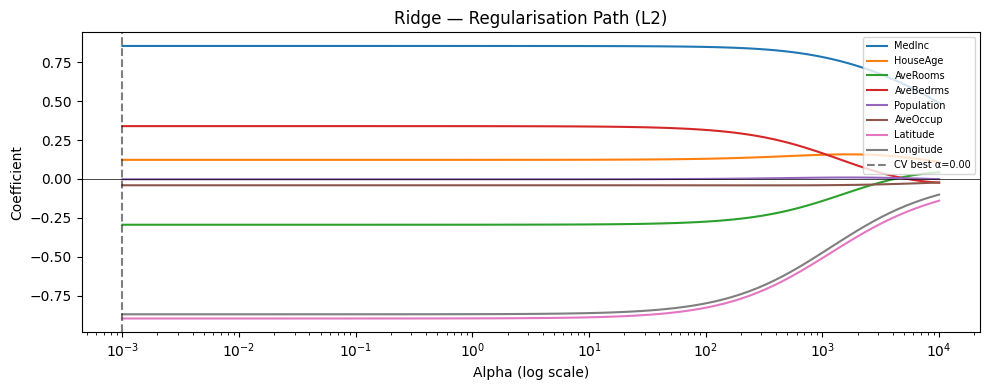

In [5]:
scaler     = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

path_alphas = np.logspace(-3, 4, 100)
ridge_coefs = np.array([
    Ridge(alpha=a).fit(X_train_sc, y_train).coef_
    for a in path_alphas
])   # (100, p)

fig, ax = plt.subplots(figsize=(10, 4))
for j, feat in enumerate(features):
    ax.semilogx(path_alphas, ridge_coefs[:, j], label=feat)
ax.axvline(best_alpha_ridge, linestyle='--', color='black', alpha=0.5,
           label=f'CV best α={best_alpha_ridge:.2f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('Coefficient')
ax.set_title('Ridge — Regularisation Path (L2)')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()

---
# Part B — Lasso Regression

$$J(\beta) = \frac{1}{2n}\|y - X\beta\|^2 + \alpha\|\beta\|_1$$

`LassoCV` fits the full regularisation path efficiently using the **LARS** algorithm
and warm starts (uses the previous solution as the starting point for the next alpha).

## LassoCV — Cross-Validated Alpha

In [6]:
pipe_lasso_cv = make_pipe(
    LassoCV(cv=5, alphas=np.logspace(-4, 1, 100), max_iter=10000, random_state=42)
).fit(X_train, y_train)

best_alpha_lasso = pipe_lasso_cv['model'].alpha_
print(f"Best alpha (LassoCV): {best_alpha_lasso:.6f}")

results.append(evaluate(pipe_lasso_cv, f'Lasso (α={best_alpha_lasso:.5f})'))

Best alpha (LassoCV): 0.000643
Lasso (α=0.00064)                   | MSE: 0.5550 | RMSE: 0.7450 | R²: 0.5765


## Lasso — Feature Selection

In [7]:
lasso_coef = pipe_lasso_cv['model'].coef_
n_zero     = np.sum(lasso_coef == 0)
print(f"Coefficients zeroed out: {n_zero} / {len(features)}")
print()
coef_df = pd.DataFrame({
    'Feature':     features,
    'Coefficient': lasso_coef,
    'Selected':    ['✓' if c != 0 else '✗  (zeroed)' for c in lasso_coef]
}).set_index('Feature').sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string())

Coefficients zeroed out: 0 / 8

            Coefficient Selected
Feature                         
Latitude      -0.889769        ✓
Longitude     -0.862271        ✓
MedInc         0.851022        ✓
AveBedrms      0.330780        ✓
AveRooms      -0.285981        ✓
HouseAge       0.123062        ✓
AveOccup      -0.040226        ✓
Population    -0.001506        ✓


## Lasso — Regularisation Path

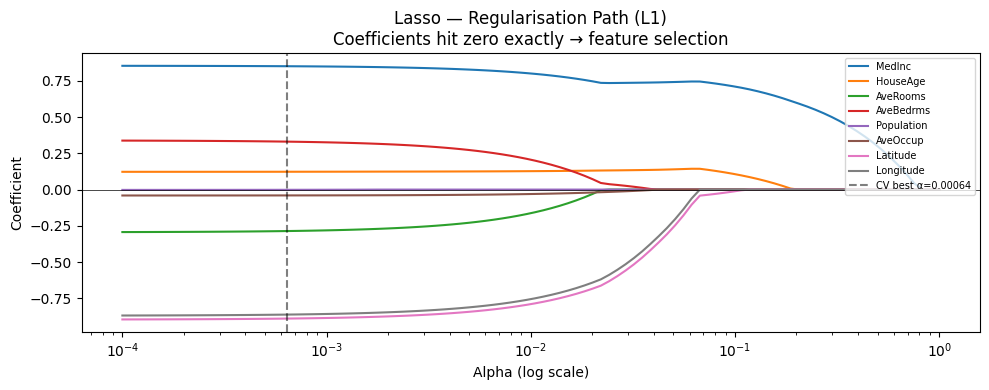

In [8]:
lasso_path_alphas = np.logspace(-4, 0, 100)
lasso_coefs = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train).coef_
    for a in lasso_path_alphas
])

fig, ax = plt.subplots(figsize=(10, 4))
for j, feat in enumerate(features):
    ax.semilogx(lasso_path_alphas, lasso_coefs[:, j], label=feat)
ax.axvline(best_alpha_lasso, linestyle='--', color='black', alpha=0.5,
           label=f'CV best α={best_alpha_lasso:.5f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('Coefficient')
ax.set_title('Lasso — Regularisation Path (L1)\nCoefficients hit zero exactly → feature selection')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()

---
# Part C — ElasticNet (L1 + L2)

$$J(\beta) = \frac{1}{2n}\|y - X\beta\|^2 + \alpha \left[ \frac{1-\rho}{2}\|\beta\|_2^2 + \rho\|\beta\|_1 \right]$$

- `l1_ratio=1` → pure Lasso
- `l1_ratio=0` → pure Ridge
- `l1_ratio` between 0 and 1 → mix of both

ElasticNet handles **grouped features** better than Lasso: when two features are highly
correlated, Lasso tends to pick one arbitrarily. ElasticNet keeps both.

In [9]:
pipe_en_cv = make_pipe(
    ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5, max_iter=10000, random_state=42
    )
).fit(X_train, y_train)

best_en = pipe_en_cv['model']
print(f"Best alpha    : {best_en.alpha_:.6f}")
print(f"Best l1_ratio : {best_en.l1_ratio_:.2f}  (1=Lasso, 0=Ridge)")

results.append(evaluate(pipe_en_cv, f'ElasticNet (α={best_en.alpha_:.5f}, l1={best_en.l1_ratio_:.2f})'))

Best alpha    : 0.000799
Best l1_ratio : 1.00  (1=Lasso, 0=Ridge)
ElasticNet (α=0.00080, l1=1.00)     | MSE: 0.5548 | RMSE: 0.7448 | R²: 0.5766


---
## Full Comparison — OLS vs Ridge vs Lasso vs ElasticNet

In [10]:
res_df = pd.DataFrame(results).set_index('Model')

res_df.style \
    .highlight_min(subset=['MSE','RMSE'], color='#c6efce') \
    .highlight_max(subset=['R2'],         color='#c6efce') \
    .format({'MSE':'{:.4f}','RMSE':'{:.4f}','R2':'{:.4f}'})

,MSE,RMSE,R2
Model,,,
OLS (no regularisation),0.5559,0.7456,0.5758
Ridge (α=0.001),0.5559,0.7456,0.5758
Lasso (α=0.00064),0.5550,0.7450,0.5765
"ElasticNet (α=0.00080, l1=1.00)",0.5548,0.7448,0.5766


## Coefficient Comparison — All 4 Models

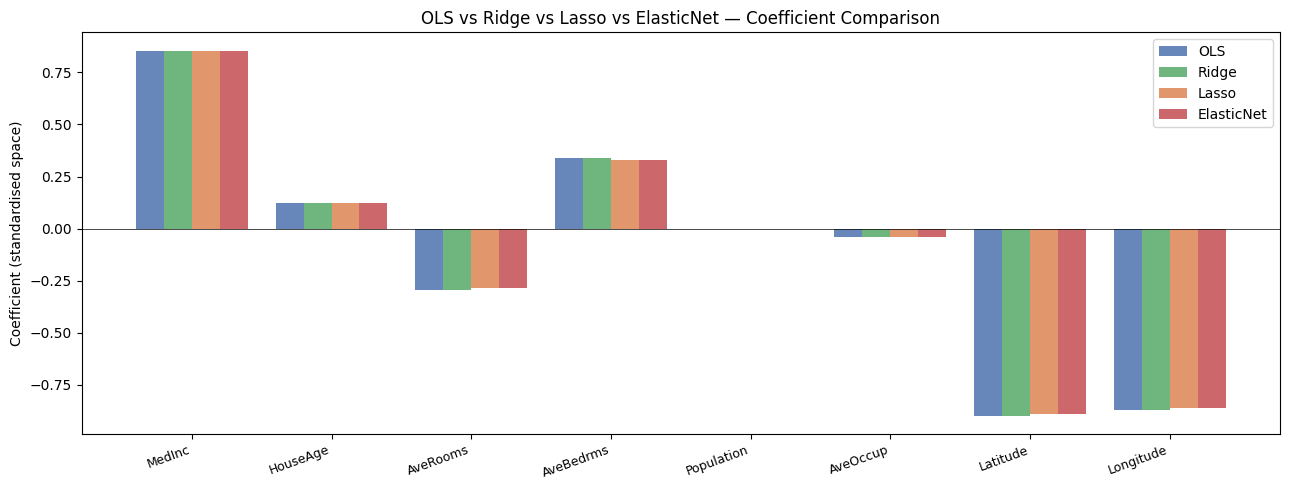

In [11]:
coef_data = {
    'OLS':        pipe_ols['model'].coef_,
    'Ridge':      pipe_ridge_cv['model'].coef_,
    'Lasso':      pipe_lasso_cv['model'].coef_,
    'ElasticNet': pipe_en_cv['model'].coef_,
}
coef_df_all = pd.DataFrame(coef_data, index=features)

x  = np.arange(len(features))
w  = 0.2
colors = ['#4C72B0','#55A868','#DD8452','#C44E52']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (col, color) in enumerate(zip(coef_data.keys(), colors)):
    ax.bar(x + (i-1.5)*w, coef_data[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Coefficient (standardised space)')
ax.set_title('OLS vs Ridge vs Lasso vs ElasticNet — Coefficient Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## LassoCV — MSE Path (Variance Across Folds)

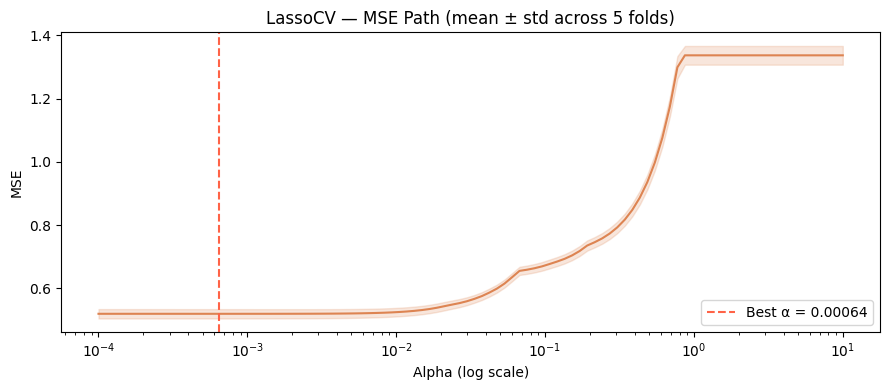

In [12]:
lasso_model   = pipe_lasso_cv['model']
mse_path      = lasso_model.mse_path_          # (n_alphas, n_folds)
mean_mse_path = mse_path.mean(axis=1)
std_mse_path  = mse_path.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lasso_model.alphas_, mean_mse_path, color='#DD8452')
ax.fill_between(lasso_model.alphas_,
                mean_mse_path - std_mse_path,
                mean_mse_path + std_mse_path,
                alpha=0.2, color='#DD8452')
ax.axvline(best_alpha_lasso, linestyle='--', color='tomato',
           label=f'Best α = {best_alpha_lasso:.5f}')
ax.set_xlabel('Alpha (log scale)'); ax.set_ylabel('MSE')
ax.set_title('LassoCV — MSE Path (mean ± std across 5 folds)')
ax.legend()
plt.tight_layout()
plt.show()

## Save Models to `../Models/`

In [13]:
os.makedirs('../Models', exist_ok=True)

joblib.dump(pipe_ridge_cv, '../Models/ridge_sklearn.joblib')
joblib.dump(pipe_lasso_cv, '../Models/lasso_sklearn.joblib')

for p in ['../Models/ridge_sklearn.joblib', '../Models/lasso_sklearn.joblib']:
    print(f"Saved → {p}  ({os.path.getsize(p)/1024:.1f} KB)")

Saved → ../Models/ridge_sklearn.joblib  (3.2 KB)
Saved → ../Models/lasso_sklearn.joblib  (8.2 KB)
